# ViFactCheck — EDA

Notebook chạy độc lập: mở trên máy cục bộ hoặc Colab và chọn **Run all**. Đọc ba CSV trong `reports/data`; không cần chạy notebook còn lại trước.

Kết quả được lưu vào `outputs/eda/`; mỗi lần chạy cập nhật các file cùng tên. Dùng `TUYEN_DIR_OVERRIDE` và `DATA_DIR_OVERRIDE` nếu cần chỉ định đường dẫn. Trên Colab, tải thư mục `reports` (gồm `data`) lên `Project/Tuyen` trong Drive và cho phép mount Drive.

Các output hiển thị cũ đã được xóa để tránh nhầm với kết quả chạy mới. Các file kết quả có sẵn trong thư mục output được giữ từ lần chạy trước.

**Phạm vi:** thống kê cấu trúc, nhãn, dữ liệu thiếu, trùng và giao nhau giữa các split, độ dài, số Evidence và chất lượng văn bản. Gợi ý preprocessing và thiết kế mô hình là kết luận tham khảo của EDA.


## A Chuẩn bị môi trường


In [1]:
# Chỉ cài gói còn thiếu; môi trường và phiên bản thực tế được ghi ở cell kế tiếp.
import importlib.util
import subprocess
import sys
packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "seaborn": "seaborn"}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("Thư viện đã sẵn sàng.")


Thư viện đã sẵn sàng.


In [2]:
import os, re, json, hashlib, platform, unicodedata, warnings
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

RANDOM_STATE = 42
LABEL_MAP = {0: "Supported", 1: "Refuted", 2: "NEI"}
LABEL_ORDER = ["Supported", "Refuted", "NEI"]
STATEMENT_COL, CONTEXT_COL, EVIDENCE_COL, LABEL_COL = "statement", "context", "evidence", "label_name"
TEXT_COLS = [STATEMENT_COL, CONTEXT_COL, EVIDENCE_COL]
required_columns = TEXT_COLS + [LABEL_COL]

# Cấu hình giao diện và phông chữ hỗ trợ tiếng Việt đa nền tảng
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option("display.max_colwidth", 160)

VERSIONS = {p: version(p) for p in packages.values()}
VERSIONS["python"] = platform.python_version()
display(pd.Series(VERSIONS, name="version").to_frame())

def note(text):
    display(Markdown("**Nhận xét từ lần chạy này:** " + text))

def save_csv(frame, filename, index=False):
    frame.to_csv(OUTPUT_DIR / filename, index=index, encoding="utf-8-sig")


,version
numpy,2.2.0
pandas,2.2.3
matplotlib,3.9.3
seaborn,0.13.2
python,3.13.9


In [3]:
# Tự động xác định đường dẫn dự án (PROJECT_ROOT, DATA_DIR, OUTPUT_DIR)
# Tương thích 100% trên Local (Mac, Windows, Linux), VS Code, JupyterLab và Google Colab.
TUYEN_DIR_OVERRIDE = ""  # Chỉ gán khi muốn ép đường dẫn thư mục gốc
DATA_DIR_OVERRIDE = ""   # Chỉ gán khi muốn ép đường dẫn thư mục dữ liệu


def resolve_notebook_paths(tuyen_override="", data_override=""):
    # 1. Xác định thư mục gốc PROJECT_DIR
    if tuyen_override:
        project_dir = Path(tuyen_override).expanduser().resolve()
    else:
        search_paths = [Path.cwd(), *Path.cwd().parents]
        if "google.colab" in sys.modules:
            search_paths.extend([
                Path("/content/Project-NLP-Fact-Checking"),
                Path("/content/drive/MyDrive/Project/Tuyen"),
                Path("/content/drive/MyDrive/Tuyen"),
                Path("/content")
            ])
        project_dir = None
        for p in search_paths:
            if (p / "data" / "processed" / "common_cleaned").is_dir():
                project_dir = p.resolve()
                break
        if project_dir is None:
            if Path.cwd().name == "notebooks":
                project_dir = Path.cwd().parent.resolve()
            else:
                project_dir = Path.cwd().resolve()

    # 2. Xác định thư mục dữ liệu DATA_DIR
    filenames = [f"vifactcheck_{split}_common_cleaned.csv" for split in ["train", "dev", "test"]]
    if data_override:
        data_candidates = [Path(data_override).expanduser().resolve()]
    else:
        data_candidates = [
            project_dir / "data" / "processed" / "common_cleaned",
            project_dir / "reports" / "data",
            project_dir / "Dataset",
            project_dir.parent / "data" / "processed" / "common_cleaned"
        ]
    data_dir = next((p for p in data_candidates if all((p / name).is_file() for name in filenames)), None)
    if data_dir is None:
        raise FileNotFoundError(
            "Thiếu bộ ba CSV common_cleaned. Đã kiểm tra các vị trí: "
            + ", ".join(str(p) for p in data_candidates)
        )

    # 3. Xác định thư mục kết quả OUTPUT_DIR
    output_dir = project_dir / "outputs" / "eda"
    return project_dir, data_dir, output_dir


if "google.colab" in sys.modules:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        pass

PROJECT_DIR, DATA_DIR, OUTPUT_DIR = resolve_notebook_paths(
    TUYEN_DIR_OVERRIDE or os.environ.get("VIFACTCHECK_TUYEN_DIR", ""),
    DATA_DIR_OVERRIDE or os.environ.get("VIFACTCHECK_DATA_DIR", ""),
)
TUYEN_DIR = PROJECT_DIR  # Giữ tên biến để tương thích với phần còn lại của notebook.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.dont_write_bytecode = True  # Không tạo __pycache__ khi nạp module đã xuất.

print("✓ Thư mục Project:", PROJECT_DIR)
print("✓ Dữ liệu:       ", DATA_DIR)
print("✓ Kết quả EDA:   ", OUTPUT_DIR)
print("✓ Lần chạy:      ", RUN_ID)
print("✓ Kết quả được lưu trực tiếp trong outputs/eda; file cùng tên sẽ được cập nhật.")


✓ Thư mục Project: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking
✓ Dữ liệu:        /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/common_cleaned
✓ Kết quả EDA:    /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/outputs/eda
✓ Lần chạy:       20260918T171327_622530Z
✓ Kết quả được lưu trực tiếp trong outputs/eda; file cùng tên sẽ được cập nhật.


## B Đọc và kiểm tra dữ liệu
Ánh xạ nhãn được giữ theo hướng dẫn của dự án. Kiểm tra schema và nhãn trên **cả Train, Dev, Test**; không suy ra ý nghĩa nhãn từ thứ tự tự động của thư viện.


**Nguồn dữ liệu thực tế:** ba CSV `common_cleaned` trong `DATA_DIR` (mặc định `reports/data`), không phải dữ liệu raw. Vì vậy EDA phản ánh phiên bản đã làm sạch chung; không suy ra rằng dữ liệu gốc không có lỗi. Muốn báo cáo tác động bước làm sạch chung cần đối chiếu thêm raw và lịch sử xử lý của nhóm.

In [4]:
data, raw_shapes, data_hashes = {}, {}, {}
for split in ["train", "dev", "test"]:
    path = DATA_DIR / f"vifactcheck_{split}_common_cleaned.csv"
    assert path.is_file(), f"Không tìm thấy {path}"
    data_hashes[split] = hashlib.sha256(path.read_bytes()).hexdigest()
    frame = pd.read_csv(path)
    raw_shapes[split] = frame.shape
    frame.columns = frame.columns.astype(str).str.strip().str.lower()
    assert frame.columns.is_unique, f"{split}: tên cột trùng sau chuẩn hóa"
    missing_cols = set(TEXT_COLS + ["labels"]) - set(frame.columns)
    assert not missing_cols, f"{split}: thiếu cột {missing_cols}"
    ids = pd.to_numeric(frame["labels"], errors="coerce")
    invalid = frame["labels"].notna() & (~ids.isin(LABEL_MAP))
    assert not invalid.any(), f"{split}: có nhãn không hợp lệ: {frame.loc[invalid, 'labels'].unique()}"
    frame[LABEL_COL] = ids.map(LABEL_MAP)
    frame["source_row"] = np.arange(len(frame))  # Vị trí 0-based trong CSV để truy vết.
    for column in TEXT_COLS:
        assert frame[column].dropna().map(lambda x: isinstance(x, str)).all(), f"{split}/{column}: không phải chuỗi"
    data[split] = frame
train_df, dev_df, test_df = [data[s] for s in ["train", "dev", "test"]]
display(train_df[required_columns].head(3))
display(train_df.dtypes.to_frame("dtype"))
print("Label mapping:", LABEL_MAP)


,statement,context,evidence,label_name
0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các...","(Chinhphu.vn) - Đây là mong muốn, gửi gắm của Phó Thủ tướng Trần Hồng Hà đến những người làm truyền hình tại lễ bế mạc Liên hoan Truyền hình toàn quốc lần t...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, cá...",Supported
1,"Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Ngày 24/3, Cơ quan Cảnh sát điều tra Công an tỉnh Bình Dương cho biết, đơn vị vừa thực hiện lệnh bắt bị can để tạm giam đối với Tô Văn Hải (sinh năm 1970, h...","Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.07...",Supported
2,"SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày ...","(PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAWACO) việc cúp nước là để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp. SAWACO cho biết ...",SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ ...,Refuted


,dtype
unnamed: 0,int64
index,int64
statement,object
context,object
annotation_id,int64
topic,object
author,object
url,object
labels,int64
evidence,object


Label mapping: {0: 'Supported', 1: 'Refuted', 2: 'NEI'}


## 3. Exploratory Data Analysis (EDA)

### 3.1. Mục tiêu
Khảo sát đặc điểm và chất lượng ViFactCheck trước khi xây dựng mô hình; cung cấp thống kê, quyết định preprocessing và cơ sở thiết kế cho nhóm.

### 3.2. Các bước thực hiện
Các cell C1–C5 giữ thứ tự chạy hiện tại; số mục PDF tương ứng được ghi trong từng tiêu đề.

### C1 Số mẫu, cấu trúc và phân bố nhãn — mục 3.2.1 và 3.2.2


,split,num_samples,source_columns,columns_after_label_mapping,columns_with_source_row,percent
0,train,5062,10,11,12,69.994469
1,dev,723,10,11,12,9.997235
2,test,1447,10,11,12,20.008296


,split,label,count,percent
0,train,Supported,1751,34.59
1,train,Refuted,1658,32.75
2,train,NEI,1653,32.66
3,dev,Supported,256,35.41
4,dev,Refuted,244,33.75
5,dev,NEI,223,30.84
6,test,Supported,508,35.11
7,test,Refuted,468,32.34
8,test,NEI,471,32.55


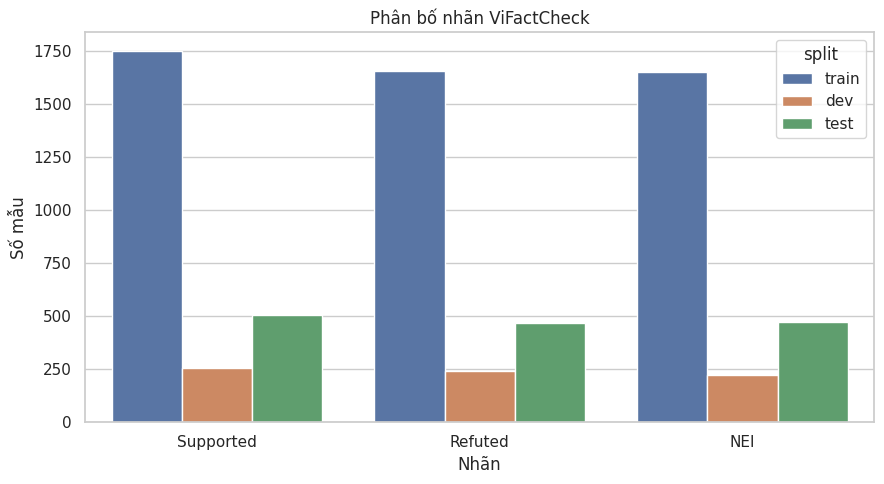

**Nhận xét từ lần chạy này:** Tổng 7,232 mẫu. Chênh lệch nhãn lớn nhất và nhỏ nhất trên Train là 1.94 điểm phần trăm. Dùng Macro-F1 làm tiêu chí chọn cấu hình; Accuracy và các metric macro đều được báo cáo. Baseline hiện tại dùng class_weight=None.

In [5]:
split_overview = pd.DataFrame([
    {"split": s, "num_samples": len(df), "source_columns": raw_shapes[s][1],
     "columns_after_label_mapping": raw_shapes[s][1] + 1, "columns_with_source_row": len(df.columns)}
    for s, df in data.items()])
split_overview["percent"] = split_overview.num_samples / split_overview.num_samples.sum() * 100
save_csv(split_overview, "01_split_overview.csv")
display(split_overview)
label_stats = pd.DataFrame([
    {"split": s, "label": label, "count": int((df[LABEL_COL] == label).sum()),
     "percent": float((df[LABEL_COL] == label).mean() * 100)}
    for s, df in data.items() for label in LABEL_ORDER])
save_csv(label_stats, "02_label_distribution.csv")
display(label_stats.round(2))
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=label_stats, x="label", y="count", hue="split", order=LABEL_ORDER, ax=ax)
ax.set(title="Phân bố nhãn ViFactCheck", xlabel="Nhãn", ylabel="Số mẫu")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "02_label_distribution.png", dpi=180); plt.show(); plt.close(fig)
train_pct = label_stats.query("split == 'train'").set_index('label')['percent']
note(f"Tổng {sum(map(len, data.values())):,} mẫu. Chênh lệch nhãn lớn nhất và nhỏ nhất trên Train là "
     f"{train_pct.max()-train_pct.min():.2f} điểm phần trăm. Dùng Macro-F1 làm tiêu chí chọn cấu hình; "
     "Accuracy và các metric macro đều được báo cáo. Baseline hiện tại dùng class_weight=None.")


### C2 Missing và blank — mục 3.2.4 Kiểm tra chất lượng dữ liệu
Đếm null riêng với chuỗi chỉ chứa khoảng trắng. Không tự điền bằng chứng giả. Nếu Test thiếu nhãn, dừng trước đánh giá để tránh âm thầm thay đổi tập đánh giá.


In [6]:
quality_missing = []
for split, frame in data.items():
    for column in required_columns:
        null = frame[column].isna()
        blank = frame[column].notna() & frame[column].astype(str).str.strip().eq("")
        quality_missing.append({"split": split, "field": column, "missing_count": int(null.sum()),
                                "blank_non_null_count": int(blank.sum())})
missing_stats = pd.DataFrame(quality_missing)
save_csv(missing_stats, "03_missing_values.csv"); display(missing_stats)
note(f"Có {missing_stats.missing_count.sum()} giá trị null và "
     f"{missing_stats.blank_non_null_count.sum()} ô blank không-null trong bốn trường khảo sát. "
     "Đây là kiểm tra tính đầy đủ, không chứng minh văn bản hoặc nhãn hoàn toàn chính xác.")


,split,field,missing_count,blank_non_null_count
0,train,statement,0,0
1,train,context,0,0
2,train,evidence,0,0
3,train,label_name,0,0
4,dev,statement,0,0
5,dev,context,0,0
6,dev,evidence,0,0
7,dev,label_name,0,0
8,test,statement,0,0
9,test,context,0,0


**Nhận xét từ lần chạy này:** Có 0 giá trị null và 0 ô blank không-null trong bốn trường khảo sát. Đây là kiểm tra tính đầy đủ, không chứng minh văn bản hoặc nhãn hoàn toàn chính xác.

### C3 Trùng dữ liệu và giao nhau giữa các split — mục 3.2.4
`keep=False` đếm mọi dòng thuộc nhóm trùng, không phải số dòng dư. Kiểm tra cặp giống hệt, Statement giống hệt và nhãn xung đột; chưa đánh giá trùng ngữ nghĩa. Giữ nguyên split chung cho vòng chạy này.


In [7]:
duplicate_stats = pd.DataFrame([
    {"split": s, "full_duplicate_rows": int(df.duplicated(required_columns, keep=False).sum()),
     "statement_evidence_duplicate_rows": int(df.duplicated([STATEMENT_COL, EVIDENCE_COL], keep=False).sum()),
     "duplicate_pair_extra_rows": int(df.duplicated([STATEMENT_COL, EVIDENCE_COL]).sum())}
    for s, df in data.items()])
save_csv(duplicate_stats, "04_duplicates.csv"); display(duplicate_stats)
overlap_rows = []
for a, b in combinations(data, 2):
    keys_a = set(zip(data[a].statement, data[a].evidence))
    keys_b = set(zip(data[b].statement, data[b].evidence))
    shared = data[a].merge(data[b], on=[STATEMENT_COL, EVIDENCE_COL], suffixes=(f"_{a}", f"_{b}"))
    overlap_rows.append({"split_a": a, "split_b": b, "exact_pairs": len(keys_a & keys_b),
                         "shared_statements": len(set(data[a].statement) & set(data[b].statement)),
                         "conflicting_pair_rows": int((shared[f"label_name_{a}"] != shared[f"label_name_{b}"]).sum())})
    save_csv(shared, f"04_{a}_{b}_overlap.csv")
overlap_summary = pd.DataFrame(overlap_rows)
save_csv(overlap_summary, "04_overlap_summary.csv"); display(overlap_summary)
# Hiển thị nhãn để kiểm chứng nhận xét Statement chung dù Evidence khác.
shared_statements = train_df.merge(dev_df, on=STATEMENT_COL, suffixes=("_train", "_dev"))
display(shared_statements[[STATEMENT_COL, "evidence_train", "evidence_dev", "label_name_train", "label_name_dev"]])
note(f"Tổng {overlap_summary.exact_pairs.sum()} cặp trùng tuyệt đối giữa các cặp split. "
     "Giữ nguyên dữ liệu để đồng nhất với nhóm và ghi nhận nguy cơ đánh giá lạc quan; "
     "nếu nhóm thay split, tất cả mô hình phải dùng cùng phiên bản mới.")


,split,full_duplicate_rows,statement_evidence_duplicate_rows,duplicate_pair_extra_rows
0,train,0,0,0
1,dev,0,0,0
2,test,0,0,0


,split_a,split_b,exact_pairs,shared_statements,conflicting_pair_rows
0,train,dev,0,1,0
1,train,test,1,1,0
2,dev,test,0,0,0


,statement,evidence_train,evidence_dev,label_name_train,label_name_dev
0,Đây là vụ hoả hoạn nghiêm trọng thứ ba trong lịch sử Cuba khi tàn phá 4 trong số 8 bể chứa tại kho nhiên liệu lớn nhất cả nước.,Đây là vụ hỏa hoạn nghiêm trọng nhất trong lịch sử Cuba và được coi là thảm họa công nghiệp có nguồn gốc tự nhiên lớn nhất từ trước tới nay. tàn phá 4 trong...,"tàn phá 4 trong số 8 bể chứa tại kho nhiên liệu bên vịnh Matanzas, Đây là vụ hỏa hoạn nghiêm trọng nhất trong lịch sử Cuba và được coi là thảm họa công nghi...",Refuted,Refuted


**Nhận xét từ lần chạy này:** Tổng 1 cặp trùng tuyệt đối giữa các cặp split. Giữ nguyên dữ liệu để đồng nhất với nhóm và ghi nhận nguy cơ đánh giá lạc quan; nếu nhóm thay split, tất cả mô hình phải dùng cùng phiên bản mới.

### C4 Độ dài văn bản và số Evidence — mục 3.2.3 Phân tích đặc điểm văn bản
Thống kê ký tự và token theo khoảng trắng trên cả ba split. Đây chưa phải token của Underthesea hay subword của Transformer; không dùng trực tiếp các giá trị này làm max_length cho Transformer.


,split,field,unit,count,mean,std,min,50%,75%,90%,95%,99%,max
0,train,statement,char,5062.0,161.25,68.11,30.0,151.0,196.00,243.0,280.0,375.78,739.0
1,train,statement,whitespace_token,5062.0,35.84,14.96,7.0,34.0,43.00,54.0,62.0,84.00,165.0
2,train,context,char,5062.0,3177.60,1722.15,314.0,2840.0,3957.00,5406.0,6186.0,9449.00,16369.0
3,train,context,whitespace_token,5062.0,693.16,374.96,71.0,608.0,865.00,1177.0,1337.0,2074.00,3602.0
4,train,evidence,char,5062.0,196.62,101.92,6.0,178.0,239.75,323.0,383.0,540.56,1205.0
5,train,evidence,whitespace_token,5062.0,43.35,22.24,2.0,39.0,53.00,71.0,85.0,119.00,259.0
6,dev,statement,char,723.0,160.11,71.02,42.0,151.0,194.00,243.8,281.9,383.34,672.0
7,dev,statement,whitespace_token,723.0,35.55,15.58,10.0,34.0,43.00,54.0,62.0,86.56,145.0
8,dev,context,char,723.0,3071.13,1558.75,314.0,2739.0,3881.50,5220.0,5923.7,8189.24,11436.0
9,dev,context,whitespace_token,723.0,670.14,339.29,71.0,597.0,846.00,1147.6,1298.0,1787.52,2534.0


,split,distinct_evidence_per_statement,num_statements
0,train,1,5058
1,train,2,2
2,dev,1,723
3,test,1,1447


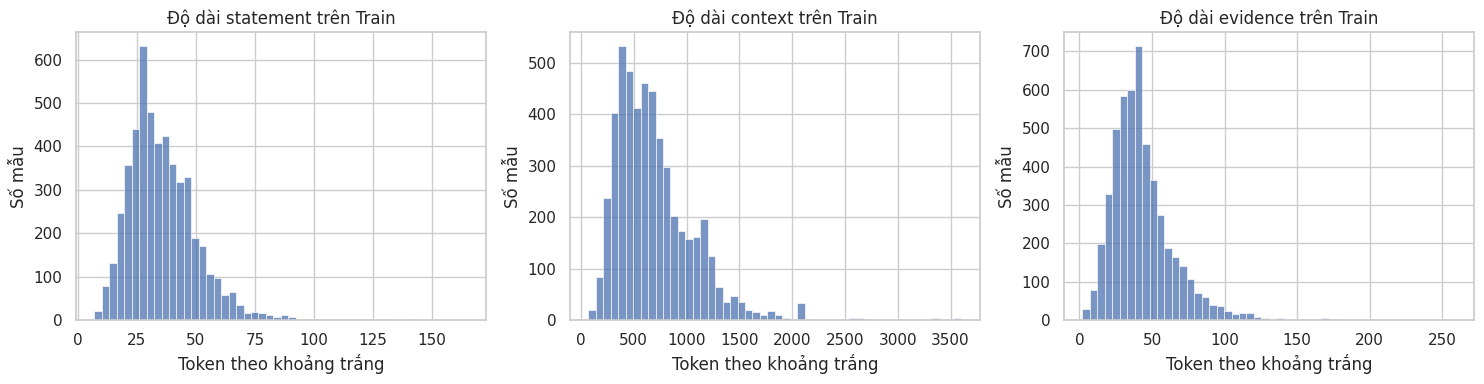

**Nhận xét từ lần chạy này:** Trung vị Train: statement 34; context 608; evidence 39. Evidence là chuỗi: đếm số chuỗi khác nhau trên mỗi Statement, không tách số câu bằng dấu chấm. Context dài hơn giúp nhóm IR/Transformer tham khảo; baseline vẫn dùng Gold Evidence theo phân công.

In [8]:
length_rows, evidence_rows = [], []
for split, frame in data.items():
    for column in TEXT_COLS:
        text = frame[column].fillna("")
        for unit, lengths in [("char", text.str.len()), ("whitespace_token", text.str.split().str.len())]:
            row = lengths.describe(percentiles=[.5, .75, .9, .95, .99]).to_dict()
            length_rows.append({"split": split, "field": column, "unit": unit, **row})
    counts = frame.groupby(STATEMENT_COL)[EVIDENCE_COL].nunique()
    for count, n_statements in counts.value_counts().sort_index().items():
        evidence_rows.append({"split": split, "distinct_evidence_per_statement": int(count),
                              "num_statements": int(n_statements)})
length_summary_all = pd.DataFrame(length_rows)
evidence_distribution = pd.DataFrame(evidence_rows)
save_csv(length_summary_all, "05_text_length_summary_all.csv")
save_csv(length_summary_all.query("split == 'train' and unit == 'whitespace_token'"), "05_text_length_summary_train.csv")
save_csv(evidence_distribution, "05_evidence_count_distribution.csv")
display(length_summary_all.round(2)); display(evidence_distribution)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for column, ax in zip(TEXT_COLS, axes):
    sns.histplot(train_df[column].fillna("").str.split().str.len(), bins=50, ax=ax)
    ax.set(title=f"Độ dài {column} trên Train", xlabel="Token theo khoảng trắng", ylabel="Số mẫu")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "05_text_length_histograms.png", dpi=180); plt.show(); plt.close(fig)
summary_train = length_summary_all.query("split == 'train' and unit == 'whitespace_token'").set_index('field')
note("Trung vị Train: " + "; ".join(f"{c} {summary_train.loc[c, '50%']:.0f}" for c in TEXT_COLS) +
     ". Evidence là chuỗi: đếm số chuỗi khác nhau trên mỗi Statement, không tách số câu bằng dấu chấm. "
     "Context dài hơn giúp nhóm IR/Transformer tham khảo; baseline vẫn dùng Gold Evidence theo phân công.")


### C5 Ký tự và định dạng bất thường — mục 3.2.4
Bổ sung kiểm tra ký tự thay thế, ký tự vô hình và Unicode chưa ở dạng NFC. Chỉ phát hiện và lưu mẫu, không tự sửa nội dung ngôn ngữ.


In [9]:
quality_patterns = {"has_url": r"https?://\S+|www\.\S+", "has_html": r"<[^>]+>",
                    "has_repeated_space": r"\s{2,}", "replacement_character": "\ufffd",
                    "zero_width_character": "[\u200b\u200c\u200d\ufeff]"}
quality_rows, issue_samples = [], []
for split, frame in data.items():
    for column in TEXT_COLS:
        text = frame[column].fillna("")
        masks = {name: text.str.contains(pattern, regex=True) for name, pattern in quality_patterns.items()}
        masks['not_nfc'] = text.map(lambda s: unicodedata.normalize("NFC", s) != s)
        for issue, mask in masks.items():
            quality_rows.append({"split": split, "field": column, "issue": issue, "count": int(mask.sum())})
            for idx in frame.index[mask][:3]:
                issue_samples.append({"split": split, "source_row": int(frame.at[idx,'source_row']),
                                      "field": column, "issue": issue, "text": frame.at[idx,column]})
quality_report = pd.DataFrame(quality_rows)
save_csv(quality_report, "06_text_quality_report.csv")
save_csv(pd.DataFrame(issue_samples, columns=['split','source_row','field','issue','text']), "06_quality_examples.csv")
display(quality_report.pivot_table(index=['split','field'], columns='issue', values='count'))
note("URL được đếm theo số ô có khớp mẫu. Kiểm tra regex không nhận ra mọi lỗi ngôn ngữ, chẳng hạn từ dính “vàchôn”. "
     "Không gọi dữ liệu hoàn toàn sạch chỉ từ kiểm tra null/regex.")


issue            has_html  has_repeated_space  has_url  not_nfc  \
split field                                                       
dev   context         0.0                 0.0     15.0      0.0   
      evidence        0.0                 0.0      1.0      0.0   
      statement       0.0                 0.0      1.0      0.0   
test  context         0.0                 0.0     33.0      0.0   
      evidence        0.0                 0.0      2.0      0.0   
      statement       0.0                 0.0      2.0      0.0   
train context         0.0                 0.0    120.0      0.0   
      evidence        0.0                 0.0      4.0      0.0   
      statement       0.0                 0.0      2.0      0.0   

issue            replacement_character  zero_width_character  
split field                                                   
dev   context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0  
test  context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0  
train context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0

**Nhận xét từ lần chạy này:** URL được đếm theo số ô có khớp mẫu. Kiểm tra regex không nhận ra mọi lỗi ngôn ngữ, chẳng hạn từ dính “vàchôn”. Không gọi dữ liệu hoàn toàn sạch chỉ từ kiểm tra null/regex.

### 3.3. Output

Báo cáo thống kê dataset: 7.232 mẫu thuộc ba tập Train/Dev/Test, với ba nhãn khá cân bằng. Các mục C1–C5 trình bày cấu trúc, phân bố nhãn, độ dài, số Evidence, giá trị thiếu, trùng lặp và định dạng bất thường. Đây là thống kê trên common_cleaned; chưa đánh giá tác động làm sạch so với raw.

Quyết định preprocessing: giữ các mẫu hợp lệ và split chung; lưu văn bản gốc để truy vết. Làm sạch Unicode, URL, HTML, khoảng trắng và tách từ; thử riêng lowercase, dấu câu và chuẩn hóa từ vựng trên Dev. Giữ số và phủ định, chưa loại stopwords. Nhãn khá cân bằng nên dùng class_weight=None và đánh giá bằng các metric macro cùng Accuracy. Chi tiết ở mục 4.1 trong notebook `Tuyen-VifactCheck_TFIDF_LogisticRegression.ipynb`.

Cơ sở lựa chọn mô hình: TF-IDF + Logistic Regression là baseline đơn giản theo thiết kế đồ án, dùng đo tín hiệu từ vựng của cặp Statement–Evidence trước khi so sánh với mô hình ngữ cảnh. EDA không chứng minh đây là mô hình tốt nhất; cấu hình tiền xử lý và n-gram phải được chọn bằng Dev.

Cơ sở thiết kế pipeline: dùng Statement + Gold Evidence để đánh giá riêng NLI. Context dài trung bình khoảng 16 lần Evidence gợi ý chia câu/đoạn trước truy hồi trong pipeline IR → IE/reranking → NLI của nhóm. Đây là định hướng, chưa phải kết quả thực nghiệm IR/IE của TV1. Max length Transformer cần kiểm tra bằng tokenizer riêng và tỷ lệ cắt trên Train/Dev. Chỉ fit Train, chọn bằng Dev, báo cáo Test; ghi nhận trùng split khi diễn giải.

Các nhận xét này gắn với ba CSV common_cleaned hiện tại; khi đổi dữ liệu, cần đối chiếu lại với bảng EDA của lần chạy mới. Định hướng mô hình và pipeline không thay thế việc đánh giá thực nghiệm.


## Lưu thông tin lần chạy EDA


In [10]:
manifest = {'part': 'eda', 'run_id': RUN_ID, 'versions': VERSIONS,
            'dataset_sha256': data_hashes, 'raw_shapes': raw_shapes,
            'overlap_summary': overlap_rows}
(OUTPUT_DIR / 'run_manifest.json').write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
(OUTPUT_DIR / 'requirements_runtime.txt').write_text(
    '\n'.join(f'{k}=={v}' for k, v in VERSIONS.items() if k != 'python') + '\n', encoding='utf-8')
print('Kết quả EDA:', OUTPUT_DIR)


Kết quả EDA: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/outputs/eda
